In [2]:
# 加载包
library(readxl)
library(hyperSpec)
library(dplyr)
library(purrr)

载入需要的程辑包：lattice

载入需要的程辑包：grid

载入需要的程辑包：ggplot2

载入需要的程辑包：xml2

Package hyperSpec, version 0.100.0

To get started, try
   vignette ("hyperspec")
   package?hyperSpec 
   vignette (package = "hyperSpec")

If you use this package please cite it appropriately.
   citation("hyperSpec")
will give you the correct reference.

The project homepage is http://hyperspec.r-forge.r-project.org




载入程辑包：'dplyr'


The following object is masked from 'package:hyperSpec':

    collapse


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [4]:
# 设置包含 Excel 文件的目录路径
data_dir <- "H:/coding_life/Academic_career/Raman_single_cell/data/B-ALL"

# 获取目录下所有 Excel 文件的列表（假设文件扩展名为 .xlsx 或 .xls）
file_list <- list.files(path = data_dir, pattern = "\\.xlsx?$", full.names = TRUE)

# 查看文件列表
print(file_list)


[1] "H:/coding_life/Academic_career/Raman_single_cell/data/B-ALL/B-ALL-1-1.xlsx"
[2] "H:/coding_life/Academic_career/Raman_single_cell/data/B-ALL/B-ALL-1-2.xlsx"
[3] "H:/coding_life/Academic_career/Raman_single_cell/data/B-ALL/B-ALL-2.xlsx"  
[4] "H:/coding_life/Academic_career/Raman_single_cell/data/B-ALL/B-ALL-3.xlsx"  


In [37]:
# 定义一个函数来读取和处理单个 Excel 文件
read_raman_excel <- function(file_path) {
  # 提取文件名（不包含路径和扩展名）
  file_base <- tools::file_path_sans_ext(basename(file_path))
  
  # 读取 Excel 文件（假设数据在第一个工作表）
  data <- read_excel(file_path, sheet = 1)
  
  # 检查数据是否至少有两列
  if (ncol(data) < 2) {
    stop(paste("文件", file_path, "的数据列数不足。"))
  }
  
  # 提取波长向量（假设第一列是波长）
  wavelength <- as.numeric(data[[1]])
  
  # 检查波长是否为数值型
  if (any(is.na(wavelength))) {
    stop(paste("文件", file_path, "的波长列包含非数值型数据。"))
  }
  
  # 提取光谱数据并转置，使每行为一个光谱
  spec <- t(as.matrix(data[, -1]))
  
  # 获取光谱的原始列名（样本名）
  original_colnames <- colnames(data[, -1])
  
  # 确保列名存在，如果缺失则生成默认名称
  if (is.null(original_colnames)) {
    original_colnames <- paste0("Spectrum", seq_len(nrow(spec)))
  } else {
    # 替换空白或缺失的列名
    original_colnames[original_colnames == ""] <- paste0("Spectrum", which(original_colnames == ""))
  }
  
  # 生成唯一的样本标签，例如 "B-ALL-1-1-1", "B-ALL-1-1-2", ...
  sample_labels <- paste0(file_base, "-", seq_len(nrow(spec)))
  
  # 创建元数据（样本标签）
  extra_data <- data.frame(sample = sample_labels)
  
  # 返回列表包含波长、光谱矩阵和元数据
  list(
    wavelength = wavelength,
    spec = spec,
    extra_data = extra_data
  )
}


In [7]:
B_ALL_1_1 <- read_excel(file_list[1])
head(B_ALL_1_1)

New names:
• `` -> `...1`


...1,1-2_Points00,1-2_Points01,1-2_Points02,1-2_Points03,1-2_Points04,1-2_Points05,1-2_Points06,1-2_Points07,1-2_Points08,⋯,1-2_Points40,1-2_Points41,1-2_Points42,1-2_Points43,1-2_Points44,1-2_Points45,1-2_Points46,1-2_Points47,1-2_Points48,1-2_Points49
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
602.126,9.162100,1.83590,2.69021,0.168456,-1.622210,9.967970,2.570170,1.79376,-0.614925,⋯,-3.735640,-0.870287,-0.5817450,1.754880,-1.270630,-0.706593,-1.32370,-0.623400,0.65737000,1.321440
604.000,6.306790,1.97646,3.68175,0.369992,-1.701490,5.248920,1.395290,1.29324,1.764020,⋯,-1.950070,-0.783032,-0.3654840,0.157330,-0.492588,0.825005,-0.20417,-1.172090,0.00290497,0.642899
605.877,3.709770,1.65639,3.21906,-0.953460,-0.685568,1.315820,0.715570,1.54829,3.491050,⋯,-0.310668,-0.800455,-0.0898126,-0.989806,0.134958,1.614250,1.39737,-0.810686,-0.38298900,0.334398
607.750,1.602500,2.27543,1.16764,-1.945780,0.392182,-1.596110,0.405736,1.95498,4.138460,⋯,0.772726,-0.140785,0.3362910,-1.639410,0.518515,1.802020,2.49599,0.250631,-0.74798800,0.145204
609.624,0.906239,2.97207,-1.47396,-1.669580,0.694812,-1.467770,0.281749,2.03823,3.966920,⋯,0.890574,0.756932,0.7224850,-1.820240,0.498921,1.420710,2.84776,1.217540,-0.84101900,0.592950
611.497,1.604890,4.16510,-2.71798,0.406149,0.449440,0.605417,0.644471,2.59082,3.803020,⋯,0.176878,1.103180,0.2434500,-1.336750,1.105710,0.802719,2.06016,2.050370,-0.70404900,1.171720


In [32]:
colnames(B_ALL_1_1[,-1])

[1] "1-2_Points00" "1-2_Points01" "1-2_Points02" "1-2_Points03" "1-2_Points04"
 [6] "1-2_Points05" "1-2_Points06" "1-2_Points07" "1-2_Points08" "1-2_Points09"
[11] "1-2_Points10" "1-2_Points11" "1-2_Points12" "1-2_Points13" "1-2_Points14"
[16] "1-2_Points15" "1-2_Points16" "1-2_Points17" "1-2_Points18" "1-2_Points19"
[21] "1-2_Points20" "1-2_Points21" "1-2_Points22" "1-2_Points23" "1-2_Points24"
[26] "1-2_Points25" "1-2_Points26" "1-2_Points27" "1-2_Points28" "1-2_Points29"
[31] "1-2_Points30" "1-2_Points31" "1-2_Points32" "1-2_Points33" "1-2_Points34"
[36] "1-2_Points35" "1-2_Points36" "1-2_Points37" "1-2_Points38" "1-2_Points39"
[41] "1-2_Points40" "1-2_Points41" "1-2_Points42" "1-2_Points43" "1-2_Points44"
[46] "1-2_Points45" "1-2_Points46" "1-2_Points47" "1-2_Points48" "1-2_Points49"

In [33]:
# 示例：为每个光谱分配一个样本编号
extra_data <- data.frame(sample=colnames(B_ALL_1_1[,-1]))
head(extra_data)

,sample
,<chr>
1,1-2_Points00
2,1-2_Points01
3,1-2_Points02
4,1-2_Points03
5,1-2_Points04
6,1-2_Points05


In [34]:
wavelength <- as.numeric(B_ALL_1_1[[1]])
spec <- t(as.matrix(B_ALL_1_1[,-1]))
spc <- new("hyperSpec", spec, wavelength,data=extra_data)
spc

hyperSpec object
   50 spectra
   2 data columns
   689 data points / spectrum
wavelength:  [numeric] 602.126 604.000 ... 1799.22 
data:  (50 rows x 2 columns)
   1. sample:  [character] 1-2_Points00 1-2_Points01 ... 1-2_Points49 
   2. spc:  [matrix, array689] 9.1621 1.8359 ... -4.34868 

In [38]:
# 读取所有文件的数据
raman_data_list <- map(file_list, read_raman_excel)

# 检查所有文件的波长是否一致
wavelengths <- map(raman_data_list, "wavelength")

# 确认所有波长相同
if (!all(map_lgl(wavelengths, ~ all(.x == wavelengths[[1]])))) {
  stop("不同文件的波长不一致，无法合并数据。")
}

# 使用第一个文件的波长作为统一波长
wavelength <- wavelengths[[1]]

# 合并所有光谱数据
# 使用 do.call(rbind, ...) 代替 bind_rows()
all_spectra <- map(raman_data_list, "spec") %>%
  do.call(rbind, .) %>%
  as.matrix()

# 查看合并后的光谱矩阵维度
print(dim(all_spectra))  # 应为 (总光谱数, 波长数)


New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
• `3-1_Points171` -> `3-1_Points171...173`
• `3-1_Points171` -> `3-1_Points171...174`


[1] 545 689


In [39]:
all_spectra

1-2_Points00,9.1621,6.30679,3.70977,1.6025,0.906239,1.60489,3.25358,4.64318,5.46186,6.02094,⋯,3.72139,3.9829,3.56018,2.96056,2.69994,2.77042,2.7381,2.20417,1.19793,-0.0560432
1-2_Points01,1.8359,1.97646,1.65639,2.27543,2.97207,4.1651,4.68778,5.24489,5.3949,5.30211,⋯,2.47603,4.79593,5.98634,6.36285,6.18751,6.90106,7.1552,6.08868,2.98009,-1.24973
1-2_Points02,2.69021,3.68175,3.21906,1.16764,-1.47396,-2.71798,-1.44679,0.77346,2.33385,2.274,⋯,2.03573,3.34505,3.93147,3.78566,3.11457,2.75371,3.21888,4.82965,7.07701,9.51576
1-2_Points03,0.168456,0.369992,-0.95346,-1.94578,-1.66958,0.406149,2.79688,4.5246,4.28713,2.88652,⋯,0.903499,-0.492251,-2.73935,-3.94007,-4.352,-4.1935,-4.26753,-4.14015,-3.21179,-1.54763
1-2_Points04,-1.62221,-1.70149,-0.685568,0.392182,0.694812,0.44944,0.33063,0.543917,1.34977,1.77671,⋯,-3.62425,-2.94152,-1.29089,0.979496,2.3803,2.40907,0.805687,-1.50512,-4.2333,-6.97322
1-2_Points05,9.96797,5.24892,1.31582,-1.59611,-1.46777,0.605417,4.14751,6.83952,8.44166,8.33098,⋯,4.94224,4.40504,3.74965,4.03485,5.1211,6.04427,5.35042,3.22053,-0.124061,-3.89335
1-2_Points06,2.57017,1.39529,0.71557,0.405736,0.281749,0.644471,1.67981,3.07354,4.39611,5.46143,⋯,3.64767,4.22785,4.5245,4.28894,2.9014,0.885258,-0.929766,-1.33706,0.285406,3.34931
1-2_Points07,1.79376,1.29324,1.54829,1.95498,2.03823,2.59082,3.61373,4.88132,5.18783,3.5588,⋯,6.56118,7.05076,6.88707,6.54768,6.23459,6.42886,7.65051,8.78269,8.74096,7.17811
1-2_Points08,-0.614925,1.76402,3.49105,4.13846,3.96692,3.80302,4.47022,5.99172,7.20819,7.06749,⋯,4.65773,5.55681,5.82554,5.4802,5.695,6.14768,7.32431,8.34575,9.21341,9.49631
1-2_Points09,-3.34496,-1.08769,0.402324,1.28357,0.998773,-0.210393,-0.970448,0.135608,2.6375,4.64773,⋯,-0.0275364,-0.0286011,1.4195,3.38577,6.77776,9.1848,10.1765,8.46694,5.66836,2.38028
1-2_Points10,3.59337,9.73219,10.7308,7.88609,3.92336,1.00272,0.27129,1.99,4.13137,5.38481,⋯,2.44888,-1.0703,-3.29721,-4.13566,-2.04333,-1.11804,-0.281861,-1.27212,-0.553734,0.890219


In [41]:
str(all_spectra)

 chr [1:545, 1:689] "9.1621" "1.8359" "2.69021" "0.168456" "-1.62221" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:545] "1-2_Points00" "1-2_Points01" "1-2_Points02" "1-2_Points03" ...
  ..$ : NULL


In [42]:
# 提取样本标签向量
all_labels <- map(raman_data_list, "extra_data") %>%
  bind_rows() %>%
  pull(sample)

# 将标签转换为因子
all_labels_factor <- as.factor(all_labels)

# 查看标签分布
print(table(all_labels_factor))


all_labels_factor
  B-ALL-1-1-1  B-ALL-1-1-10  B-ALL-1-1-11  B-ALL-1-1-12  B-ALL-1-1-13 
            1             1             1             1             1 
 B-ALL-1-1-14  B-ALL-1-1-15  B-ALL-1-1-16  B-ALL-1-1-17  B-ALL-1-1-18 
            1             1             1             1             1 
 B-ALL-1-1-19   B-ALL-1-1-2  B-ALL-1-1-20  B-ALL-1-1-21  B-ALL-1-1-22 
            1             1             1             1             1 
 B-ALL-1-1-23  B-ALL-1-1-24  B-ALL-1-1-25  B-ALL-1-1-26  B-ALL-1-1-27 
            1             1             1             1             1 
 B-ALL-1-1-28  B-ALL-1-1-29   B-ALL-1-1-3  B-ALL-1-1-30  B-ALL-1-1-31 
            1             1             1             1             1 
 B-ALL-1-1-32  B-ALL-1-1-33  B-ALL-1-1-34  B-ALL-1-1-35  B-ALL-1-1-36 
            1             1             1             1             1 
 B-ALL-1-1-37  B-ALL-1-1-38  B-ALL-1-1-39   B-ALL-1-1-4  B-ALL-1-1-40 
            1             1             1             1    

In [43]:
# 创建元数据数据框
extra_data <- data.frame(sample = all_labels_factor)

# 创建 hyperSpec 对象，使用命名参数并提供所有必要的信息
raman_hs <- new("hyperSpec",
               spc = all_spectra,
               wavelength = wavelength,
               data = extra_data,
               labels = list(
                 wavelength = "Wavelength (cm^-1)",  # 根据您的数据实际单位调整
                 spc = "Intensity"
               )
)

# 查看 hyperSpec 对象的基本信息
print(raman_hs)


Warning message in .local(.Object, ...):
"spectra matrix is converted from NULL to numeric."


hyperSpec object
   545 spectra
   2 data columns
   689 data points / spectrum
wavelength:  [numeric] 602.126 604.000 ... 1799.22 
data:  (545 rows x 2 columns)
   1. sample:  [factor] B-ALL-1-1-1 B-ALL-1-1-2 ... B-ALL-3-173 
   2. spc: Intensity [matrix, array689] 9.1621 1.8359 ... -3.2574 


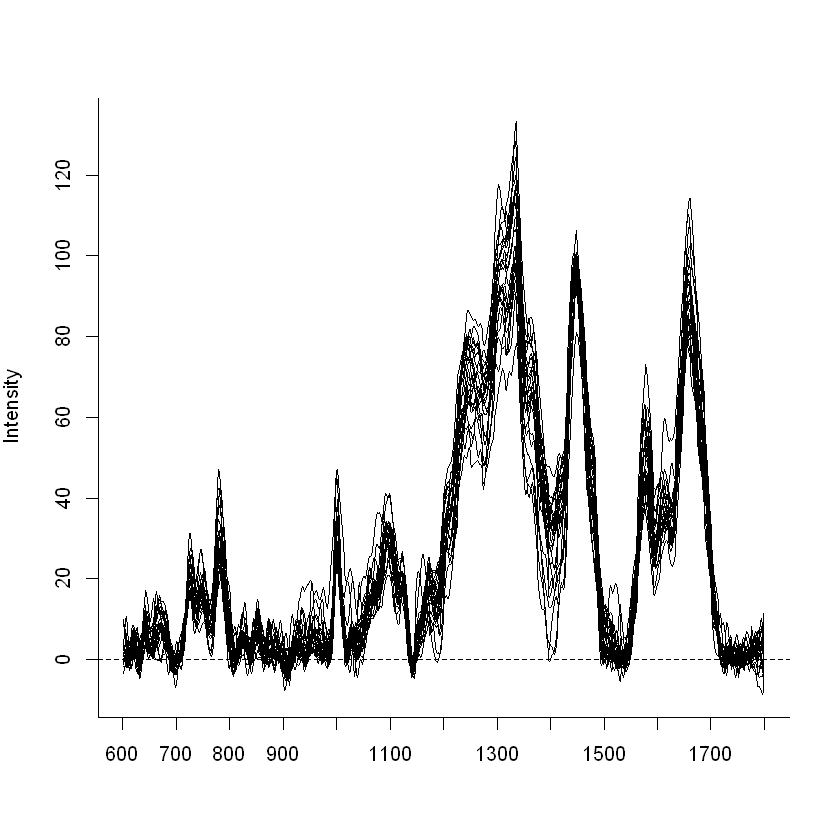

In [47]:
plot(raman_hs)